# Fourier Analysis of Molecular Hamiltonian Expectation Values

Using VQE, we want to compute 

\begin{equation}
E(\theta) = \langle \psi(\theta) | H | \psi(\theta) \rangle
\end{equation}

where $H$ is a molecular hamiltonian. For the molecule of $H_2$, we expect to obtain (Kandala et al, 2017)

\begin{equation}
H = c_0 II + c_1 IZ + c_2 ZI + c_3 ZZ + c_4 XX + c_5 YY
\end{equation}

and the expectation value in the VQE state should be something like

\begin{equation}
E(\theta) = a + b\cos(\theta) + c\sin(\theta)
\end{equation}


In [1]:
from src.vqe.hamiltonian import (
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

ferm_op, constant_energy = build_electronic_hamiltonian(
    atom_string="H 0 0 0; H 0 0 0.74",
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op = build_qubit_hamiltonian(ferm_op, mapper="jw")
terms = pauli_terms_from_qubit_hamiltonian(qubit_op)

print("constant_energy:", constant_energy)
for pauli, coeff in terms:
    print(coeff, pauli)

constant_energy: 0.7151043390810812
-0.8121706072487132 IIII
0.17141282644776906 IIIZ
-0.2234315369081336 IIZI
0.12062523483390414 IIZZ
0.17141282644776912 IZII
0.16868898170361202 IZIZ
-0.2234315369081336 ZIII
0.16592785033770333 ZIIZ
0.04530261550379917 YYYY
0.04530261550379917 XXYY
0.04530261550379917 YYXX
0.04530261550379917 XXXX
0.16592785033770333 IZZI
0.1744128761226153 ZIZI
0.12062523483390414 ZZII


In [1]:
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
)

atom = "H 0 0 0; H 0 0 0.74"

problem = build_electronic_problem(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

ferm_op, const = build_electronic_hamiltonian(
    atom_string=atom,
    basis="sto-3g",
    active_space=(2, 2),
    freeze_core=False,
)

qubit_op_2q = build_qubit_hamiltonian(
    ferm_op,
    mapper="parity",
    z2symmetry_reduction=False,   # mantém em 2 qubits
    problem=problem,
    num_particles=problem.num_particles,
)

print("num_qubits:", qubit_op_2q.num_qubits)
print(pauli_terms_from_qubit_hamiltonian(qubit_op_2q)[:10])

num_qubits: 2
[('II', -1.053421076916521), ('IZ', 0.39484436335590256), ('ZI', -0.3948443633559026), ('ZZ', -0.011246157150820668), ('XX', 0.1812104620151967)]


In [2]:
import numpy as np
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import build_qubit_hamiltonian

# Build three H2 Hamiltonians from the same electronic problem
qubit_ops = {
    "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
    "2q_parity": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=False,
        problem=problem,
        num_particles=problem.num_particles,
    ),
    "1q_parity_z2": build_qubit_hamiltonian(
        ferm_op,
        mapper="parity",
        z2symmetry_reduction=True,
        problem=problem,
        num_particles=problem.num_particles,
    ),
}

rows = []
for label, qop in qubit_ops.items():
    ansatz = build_ansatz(
        name="real_amplitudes",
        num_qubits=qop.num_qubits,
        reps=2,
    )
    optimizer = get_optimizer("cobyla", max_iter=200)

    vqe_res = run_vqe(
        qubit_op=qop,
        ansatz=ansatz,
        optimizer=optimizer,
        constant_energy=float(const),
        seed=137,
    )

    exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
    exact_total = float(np.real(exact.eigenvalue) + float(const))

    rows.append({
        "hamiltonian": label,
        "num_qubits": qop.num_qubits,
        "vqe_total_energy": float(vqe_res["energy"]),
        "exact_total_energy": exact_total,
        "abs_error": abs(float(vqe_res["energy"]) - exact_total),
        "eval_count": int(vqe_res["eval_count"]),
    })

rows = sorted(rows, key=lambda x: x["num_qubits"], reverse=True)
for row in rows:
    print(row)

{'hamiltonian': '4q_jw', 'num_qubits': 4, 'vqe_total_energy': -1.1167590753609047, 'exact_total_energy': -1.137283834488501, 'abs_error': 0.020524759127596326, 'eval_count': 200}
{'hamiltonian': '2q_parity', 'num_qubits': 2, 'vqe_total_energy': -1.1372838335556938, 'exact_total_energy': -1.1372838344885021, 'abs_error': 9.32808275067032e-10, 'eval_count': 76}
{'hamiltonian': '1q_parity_z2', 'num_qubits': 1, 'vqe_total_energy': -1.137283834480362, 'exact_total_energy': -1.1372838344885003, 'abs_error': 8.138378859712248e-12, 'eval_count': 36}


## Ground-State Energy Curve vs Interatomic Distance

This section sweeps the H-H bond distance and computes the ground-state energy with VQE for each Hamiltonian encoding:
- `4q_jw`
- `2q_parity`
- `1q_parity_z2`

For each case, we also compute the exact minimum eigenvalue of the same qubit Hamiltonian for reference.

,distance,hamiltonian,num_qubits,num_terms,vqe_total_energy,exact_total_energy,abs_error,eval_count
0,0.500000,4q_jw,4,15,-1.041780,-1.055160,1.337930e-02,120
1,0.500000,2q_parity,2,5,-1.055160,-1.055160,1.138639e-09,70
2,0.500000,1q_parity_z2,1,3,-1.055160,-1.055160,9.767960e-10,35
3,0.605263,4q_jw,4,15,-1.102772,-1.118138,1.536626e-02,120
4,0.605263,2q_parity,2,5,-1.118138,-1.118138,2.186846e-09,64
5,0.605263,1q_parity_z2,1,3,-1.118138,-1.118138,7.967849e-12,33
6,0.710526,4q_jw,4,15,-1.117483,-1.136774,1.929162e-02,120
7,0.710526,2q_parity,2,5,-1.136774,-1.136774,1.749782e-09,75
8,0.710526,1q_parity_z2,1,3,-1.136774,-1.136774,1.093393e-09,36


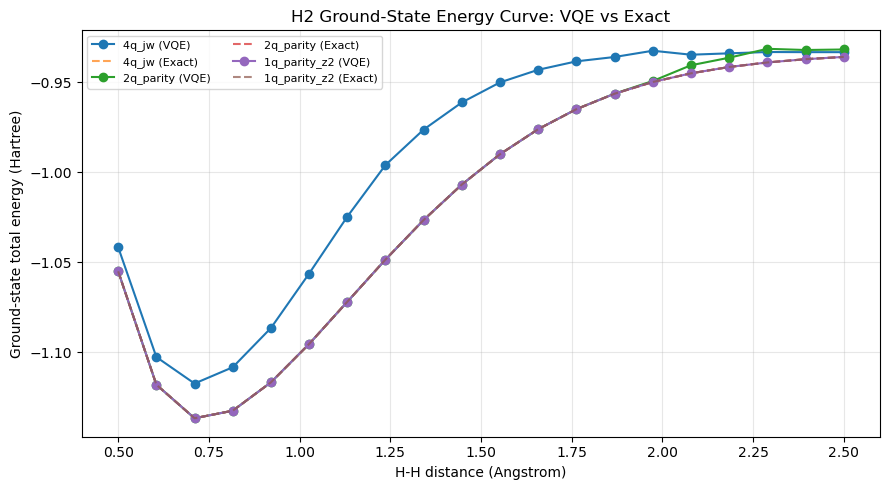

,hamiltonian,num_qubits,mean_abs_error,max_abs_error,mean_eval_count
2,4q_jw,4,2.522873e-02,5.254063e-02,120.00
1,2q_parity,2,1.353212e-03,7.575913e-03,102.55
0,1q_parity_z2,1,3.895955e-10,1.432185e-09,35.95


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver

from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

distances = np.linspace(0.5, 2.5, 20)
basis = "sto-3g"
active_space = (2, 2)

rows = []
for d in distances:
    atom = f"H 0 0 0; H 0 0 {d}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "abs_error": abs(float(vqe_res["energy"]) - exact_total),
            "eval_count": int(vqe_res["eval_count"]),
        })

df = pd.DataFrame(rows)
display(df.head(9))

plt.figure(figsize=(9, 5))
for label in df["hamiltonian"].unique():
    sub = df[df["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")
    plt.plot(sub["distance"], sub["exact_total_energy"], linestyle="--", alpha=0.7, label=f"{label} (Exact)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("H2 Ground-State Energy Curve: VQE vs Exact")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

summary = (
    df.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_abs_error=("abs_error", "mean"),
        max_abs_error=("abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(summary)

## Comparison with PySCF FCI Curve (same distance points)

Here we load the cached FCI data generated in the other notebook (`00_fci_cache_baseline.ipynb`) for `H2/sto-3g`, and recompute VQE/exact energies on the **same FCI distances** (no interpolation).

This gives a fair point-by-point comparison against the PySCF FCI reference.

Using FCI cache file: fci_a29985a3fb.csv
FCI distance range: (0.34375, 2.0625)


,distance,hamiltonian,num_qubits,num_terms,fci_pyscf_energy,vqe_total_energy,exact_total_energy,vqe_vs_fci_abs_error,exact_vs_fci_abs_error,eval_count
0,0.343750,4q_jw,4,15,-0.769849,-0.761123,-0.769849,8.726313e-03,1.332268e-15,120
1,0.343750,2q_parity,2,5,-0.769849,-0.769849,-0.769849,4.286542e-09,4.440892e-16,57
2,0.343750,1q_parity_z2,1,3,-0.769849,-0.769849,-0.769849,1.275395e-09,2.220446e-15,37
3,0.361111,4q_jw,4,15,-0.821464,-0.812375,-0.821464,9.088818e-03,4.884981e-15,120
4,0.361111,2q_parity,2,5,-0.821464,-0.821464,-0.821464,6.745839e-09,2.664535e-15,72
5,0.361111,1q_parity_z2,1,3,-0.821464,-0.821464,-0.821464,9.171059e-10,1.776357e-15,34
6,0.378472,4q_jw,4,15,-0.866377,-0.856688,-0.866377,9.688408e-03,8.881784e-16,120
7,0.378472,2q_parity,2,5,-0.866377,-0.866377,-0.866377,7.701941e-10,3.552714e-15,64
8,0.378472,1q_parity_z2,1,3,-0.866377,-0.866377,-0.866377,1.136696e-09,3.108624e-15,39


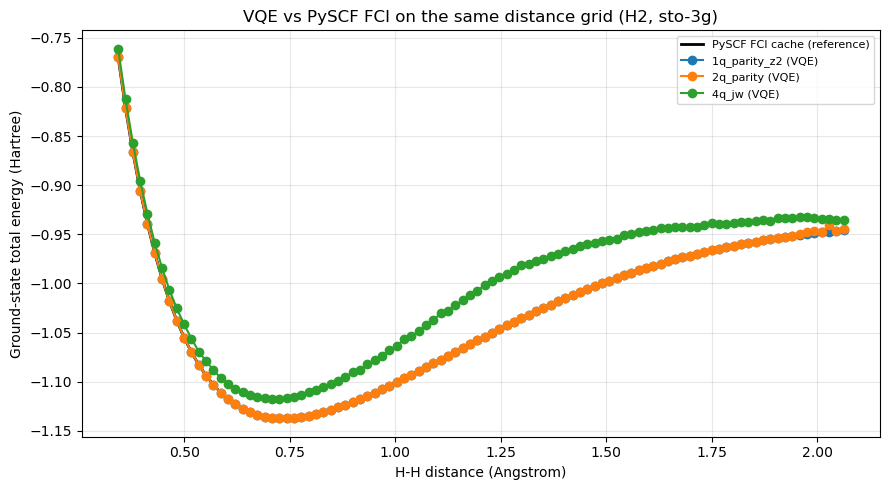

,hamiltonian,num_qubits,mean_vqe_vs_fci_error,max_vqe_vs_fci_error,mean_exact_vs_fci_error,max_exact_vs_fci_error,mean_eval_count
2,4q_jw,4,2.961466e-02,5.406981e-02,2.098322e-15,8.881784e-15,120.00
1,2q_parity,2,1.562599e-04,6.855073e-03,1.054712e-15,4.440892e-15,97.66
0,1q_parity_z2,1,5.855692e-10,5.352185e-09,9.992007e-16,3.108624e-15,37.37


In [6]:
from pathlib import Path

from qiskit_algorithms.minimum_eigensolvers import NumPyMinimumEigensolver
from src.vqe.ansatz import build_ansatz
from src.vqe.optimizer import get_optimizer
from src.vqe.vqe_runner import run_vqe
from src.vqe.hamiltonian import (
    build_electronic_problem,
    build_electronic_hamiltonian,
    build_qubit_hamiltonian,
    pauli_terms_from_qubit_hamiltonian,
 )

# Resolve project root whether notebook cwd is root or notebooks/
cwd = Path.cwd().resolve()
project_root = cwd if (cwd / "data").exists() else cwd.parent

fci_dir = project_root / "data" / "H2" / "sto-3g"
fci_files = sorted(fci_dir.glob("fci_*.csv"), key=lambda p: p.stat().st_mtime)
if not fci_files:
    raise FileNotFoundError(f"No FCI cache files found in {fci_dir}")

fci_file = fci_files[-1]
fci_df = pd.read_csv(fci_file).sort_values("distance").reset_index(drop=True)

print("Using FCI cache file:", fci_file.name)
print("FCI distance range:", (float(fci_df["distance"].min()), float(fci_df["distance"].max())))

basis = "sto-3g"
active_space = (2, 2)

# Leave as None to use all FCI points (fair comparison).
max_points = None
if max_points is None:
    distances_eval = fci_df["distance"].values
else:
    distances_eval = fci_df["distance"].values[:max_points]

rows_fair = []
for d in distances_eval:
    atom = f"H 0 0 0; H 0 0 {float(d)}"

    problem = build_electronic_problem(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )
    ferm_op, const = build_electronic_hamiltonian(
        atom_string=atom,
        basis=basis,
        active_space=active_space,
        freeze_core=False,
    )

    qubit_ops = {
        "4q_jw": build_qubit_hamiltonian(ferm_op, mapper="jw"),
        "2q_parity": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=False,
            problem=problem,
            num_particles=problem.num_particles,
        ),
        "1q_parity_z2": build_qubit_hamiltonian(
            ferm_op,
            mapper="parity",
            z2symmetry_reduction=True,
            problem=problem,
            num_particles=problem.num_particles,
        ),
    }

    fci_ref = float(fci_df.loc[np.isclose(fci_df["distance"].values, d), "energy"].iloc[0])

    for label, qop in qubit_ops.items():
        ansatz = build_ansatz(
            name="real_amplitudes",
            num_qubits=qop.num_qubits,
            reps=2,
        )
        optimizer = get_optimizer("cobyla", max_iter=120)

        vqe_res = run_vqe(
            qubit_op=qop,
            ansatz=ansatz,
            optimizer=optimizer,
            constant_energy=float(const),
            seed=137,
        )

        exact = NumPyMinimumEigensolver().compute_minimum_eigenvalue(qop)
        exact_total = float(np.real(exact.eigenvalue) + float(const))

        rows_fair.append({
            "distance": float(d),
            "hamiltonian": label,
            "num_qubits": qop.num_qubits,
            "num_terms": len(pauli_terms_from_qubit_hamiltonian(qop)),
            "fci_pyscf_energy": fci_ref,
            "vqe_total_energy": float(vqe_res["energy"]),
            "exact_total_energy": exact_total,
            "vqe_vs_fci_abs_error": abs(float(vqe_res["energy"]) - fci_ref),
            "exact_vs_fci_abs_error": abs(exact_total - fci_ref),
            "eval_count": int(vqe_res["eval_count"]),
        })

compare_fair = pd.DataFrame(rows_fair)
display(compare_fair.head(9))

plt.figure(figsize=(9, 5))
fci_plot = fci_df[fci_df["distance"].isin(distances_eval)]
plt.plot(
    fci_plot["distance"],
    fci_plot["energy"],
    color="black",
    linewidth=2,
    label="PySCF FCI cache (reference)",
 )

for label in sorted(compare_fair["hamiltonian"].unique()):
    sub = compare_fair[compare_fair["hamiltonian"] == label].sort_values("distance")
    plt.plot(sub["distance"], sub["vqe_total_energy"], marker="o", label=f"{label} (VQE)")

plt.xlabel("H-H distance (Angstrom)")
plt.ylabel("Ground-state total energy (Hartree)")
plt.title("VQE vs PySCF FCI on the same distance grid (H2, sto-3g)")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

fci_summary_fair = (
    compare_fair.groupby(["hamiltonian", "num_qubits"], as_index=False)
    .agg(
        mean_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "mean"),
        max_vqe_vs_fci_error=("vqe_vs_fci_abs_error", "max"),
        mean_exact_vs_fci_error=("exact_vs_fci_abs_error", "mean"),
        max_exact_vs_fci_error=("exact_vs_fci_abs_error", "max"),
        mean_eval_count=("eval_count", "mean"),
    )
    .sort_values("num_qubits", ascending=False)
)
display(fci_summary_fair)